In [4]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [5]:
# reading dataset
df = pd.read_csv('./height-weight.csv')

In [6]:
# displaying the table
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Weight vs Height')

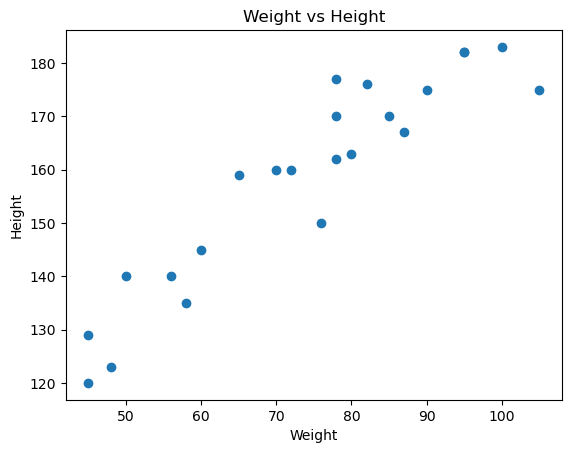

In [7]:
# scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weight vs Height')

In [8]:
# correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


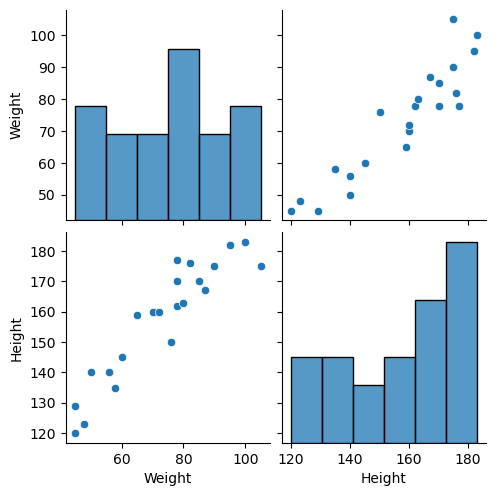

In [9]:
# seaborn for visualization 

import seaborn as sns
sns.pairplot(df)

In [12]:
# Independent and Dependent features
X = df[['Weight']] # independent feature should be a data frame or in 2D array
y = df['Height']  # dependent feature can be a series or in 1D array

In [13]:
x_series = df['Weight']
np.array(x_series).shape

(23,)

In [14]:
np.array(y).shape

(23,)

In [15]:
# train test split
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [20]:
# standardization
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()
scaler.fit_transform(X_train)

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [22]:
X_test = scaler.transform(X_test)

In [23]:
# apply linear regression
from sklearn.linear_model import LinearRegression

In [24]:
regression = LinearRegression()

In [25]:
regression.fit(X_train, y_train)

LinearRegression()

In [28]:
print("Coefficient:", regression.coef_)
print("Intercept:", regression.intercept_)

Coefficient: [1.04792503]
Intercept: 80.52684512622542


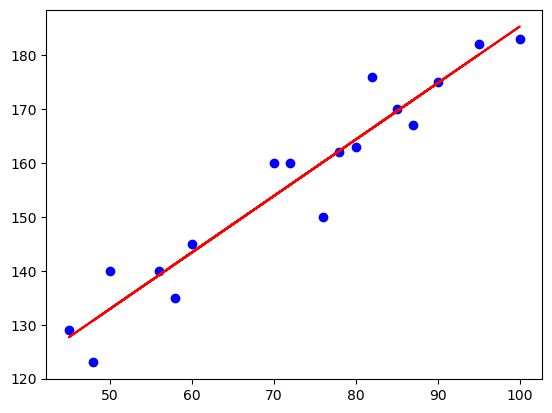

In [30]:
# plot the training data plot best fit line
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, regression.predict(X_train), color='red')

In [33]:
# Prediction for test data
y_predit = regression.predict(X_test)

d:\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [34]:
# Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [35]:
mse = mean_squared_error(y_test, y_predit)
mae = mean_absolute_error(y_test, y_predit)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

MSE: 7276.932884039703
MAE: 82.97662409755102
RMSE: 85.3049405605543


In [36]:
# R Square
from sklearn.metrics import r2_score

In [37]:
score = r2_score(y_test, y_predit)
print("R2 Score:", score)

R2 Score: -15.723241865651406


In [38]:
# Adjusted R Square
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

-19.904052332064257

In [39]:
# OLS Linear Regression
import statsmodels.api as sm

In [40]:
model = sm.OLS(y_train, X_train).fit()  # ordinary least squares

In [41]:
prediction = model.predict(X_test)
print (prediction)

[ 0.70487577  0.70487577 -3.5018828   2.87199382 -0.95233215  4.14676914]
